In [57]:
from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from typing import Optional, Annotated, TypedDict
import operator

In [35]:
llm = ChatGroq(
    model = "openai/gpt-oss-120b",
    max_tokens=512,
    temperature=0
)

In [36]:
class EvaluationSchema(BaseModel):
    feedback: str = Field(description="Detailed feedback of essay")
    score: int = Field(description="Score of essay between 1-10")

In [37]:
structured_llm = llm.with_structured_output(EvaluationSchema)

In [38]:
class LLMState(TypedDict):
    topic: str
    essay: str

    clarity_of_thought: str
    depth_of_analysis: str
    language_correctness: str
    final_summary: str

    individual_scores: Annotated[list[int], operator.add]
    avg_score: float
    

In [39]:
def generate_essay(state: LLMState) -> dict:

    prompt = f"Generate a short essay on the topic: {state["topic"]}"

    essay = llm.invoke(prompt).content

    return {"essay": essay}

In [46]:
def clarity_of_thought(state: LLMState) -> dict:

    prompt = f"Judge the essay on the basis of clarity of thought and give a short feedback. Essay: {state["essay"]}"
    
    clarity_of_thought = structured_llm.invoke(prompt)
    
    return {
        "clarity_of_thought": clarity_of_thought.feedback,
        "individual_scores": [clarity_of_thought.score]
    }

In [47]:
def depth_of_analysis(state: LLMState) -> dict:

    prompt = f"Judge the essay on the basis of depth of analysis and give a short feedback. Essay: {state["essay"]}"
    
    depth_of_analysis = structured_llm.invoke(prompt)
    
    return {
        "depth_of_analysis": depth_of_analysis.feedback,
        "individual_scores": [depth_of_analysis.score]
    }

In [48]:
def language_correctness(state: LLMState) -> dict:

    prompt = f"Judge the essay on the basis of language correctness and give a short feedback. Essay: {state["essay"]}"
    
    language_correctness = structured_llm.invoke(prompt)
    
    return {
        "language_correctness": language_correctness.feedback,
        "individual_scores": [language_correctness.score]
    }

In [58]:
def final_summary(state: LLMState) -> LLMState:
    clarity_of_thought = state["clarity_of_thought"]
    depth_of_analysis = state["depth_of_analysis"]
    language_correctness = state["language_correctness"]

    # Final Summary
    prompt = f"""
    Provide a short summary of an essay based on the following aspects

    Clarity of Score: {clarity_of_thought}
    Depth of Analysis: {depth_of_analysis}
    Language Correctness: {language_correctness}
    """

    final_summary = llm.invoke(prompt).content

    # Average score
    avg_score = sum(state["individual_scores"])/len(state["individual_scores"])
    avg_score = round(avg_score, 2)

    return {"final_summary": final_summary, "avg_score": avg_score}


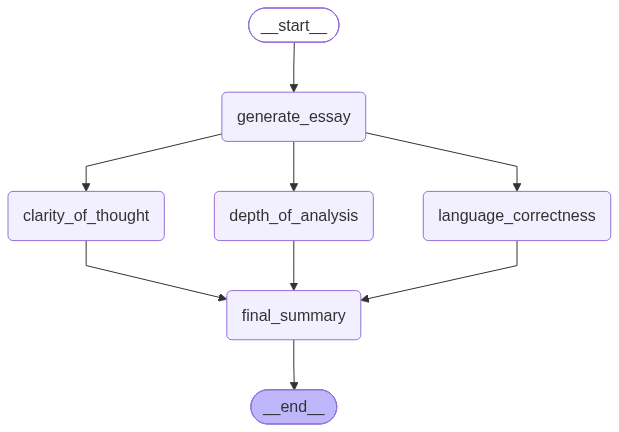

In [59]:
graph = StateGraph(LLMState)

graph.add_node("generate_essay", generate_essay)
graph.add_node("clarity_of_thought", clarity_of_thought)
graph.add_node("depth_of_analysis", depth_of_analysis)
graph.add_node("language_correctness", language_correctness)
graph.add_node("final_summary", final_summary)

graph.add_edge(START, "generate_essay")

graph.add_edge("generate_essay", "clarity_of_thought")
graph.add_edge("generate_essay", "depth_of_analysis")
graph.add_edge("generate_essay", "language_correctness")

graph.add_edge("clarity_of_thought", "final_summary")
graph.add_edge("depth_of_analysis", "final_summary")
graph.add_edge("language_correctness", "final_summary")

graph.add_edge("final_summary", END)

workflow = graph.compile()
workflow

In [60]:
initial_state = {
    "topic": "Issues in Indian Education System"
}

output_state = workflow.invoke(initial_state)

output_state

{'topic': 'Issues in Indian Education System',
 'essay': '**Issues in the Indian Education System**\n\nIndia’s education system, one of the largest in the world, has made remarkable strides in enrolment and literacy over the past few decades. Yet, beneath the impressive statistics lie deep‑rooted challenges that hinder the sector’s ability to deliver equitable, high‑quality learning for all. The most pressing issues can be grouped into four inter‑related domains: access and equity, quality of instruction, curriculum relevance, and systemic governance.\n\n---\n\n### 1. Access and Equity  \n\n**a. Rural‑Urban Divide** – While urban centres boast modern schools and abundant resources, many rural districts still lack basic infrastructure such as classrooms, toilets, and reliable electricity. According to the 2022 ASER report, nearly 30\u202f% of rural schools operate without a functional library or computer lab, limiting students’ exposure to contemporary learning tools.  \n\n**b. Socio‑Ec